# FOOTBALL ANALYTICS & PLAYER MODELING
### SIDE PROJECT


This notebook focuses on analyzing football player statistics and building Machine Learning models to evaluate and predict player performance.

The project begins with data cleaning and preparation, to ensure a reliable dataset. This is followed by a visual exploration and analysis of key performance metrics and the correlations between them, providing insights of the players performance and laying the foundation for model development.

The model development step involved defining the objectives and selecting the most suitable model for each task:

1. Performance Prediction – Random Forest Regressor to predict goals and assists (Time series models were not applicable due to the structure of the dataset.)

2. Player Similarity – K-Means clustering to identify players with similar statistical profiles

3. Performance Classification – Random Forest Classifier to label players as overperforming, underperforming, or well-rated

The final goal is to create models that can be integrated into a football analytics web application, allowing the project to go through all the typical phases of a machine learning workflow, from data preparation to deployment.

### 1. DATA CLEANING AND PREPARATION

In [1]:
import pandas as pd
data = pd.read_csv("big_5_players_stats_2023_2024.csv")
data.head(5)

,Rank,Player,Nation,Position,Squad,Competition,Age,Year_Born,Playing Time_MP,Playing Time_Starts,...,Per 90 Minutes_Gls,Per 90 Minutes_Ast,Per 90 Minutes_G+A,Per 90 Minutes_G-PK,Per 90 Minutes_G+A-PK,Per 90 Minutes_xG,Per 90 Minutes_xAG,Per 90 Minutes_xG+xAG,Per 90 Minutes_npxG,Per 90 Minutes_npxG+xAG
0,1,Max Aarons,eng ENG,DF,Bournemouth,eng Premier League,23,2000,20,13,...,0.00,0.07,0.07,0.00,0.07,0.00,0.06,0.06,0.00,0.06
1,2,Brenden Aaronson,us USA,"MF,FW",Union Berlin,de Bundesliga,22,2000,30,14,...,0.14,0.14,0.28,0.14,0.28,0.14,0.13,0.27,0.14,0.27
2,3,Paxten Aaronson,us USA,MF,Eint Frankfurt,de Bundesliga,19,2003,7,1,...,0.00,0.89,0.89,0.00,0.89,0.11,0.07,0.19,0.11,0.19
3,4,Keyliane Abdallah,fr FRA,FW,Marseille,fr Ligue 1,17,2006,1,0,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
4,5,Yunis Abdelhamid,ma MAR,DF,Reims,fr Ligue 1,35,1987,31,31,...,0.13,0.00,0.13,0.10,0.10,0.11,0.01,0.12,0.09,0.09


In [2]:
data.shape

(2958, 37)

In [3]:
print(data.columns)

Index(['Rank', 'Player', 'Nation', 'Position', 'Squad', 'Competition', 'Age',
       'Year_Born', 'Playing Time_MP', 'Playing Time_Starts',
       'Playing Time_Min', 'Playing Time_90s', 'Performance_Gls',
       'Performance_Ast', 'Performance_G+A', 'Performance_G-PK',
       'Performance_PK', 'Performance_PKatt', 'Performance_CrdY',
       'Performance_CrdR', 'Expected_xG', 'Expected_npxG', 'Expected_xAG',
       'Expected_npxG+xAG', 'Progression_PrgC', 'Progression_PrgP',
       'Progression_PrgR', 'Per 90 Minutes_Gls', 'Per 90 Minutes_Ast',
       'Per 90 Minutes_G+A', 'Per 90 Minutes_G-PK', 'Per 90 Minutes_G+A-PK',
       'Per 90 Minutes_xG', 'Per 90 Minutes_xAG', 'Per 90 Minutes_xG+xAG',
       'Per 90 Minutes_npxG', 'Per 90 Minutes_npxG+xAG'],
      dtype='object')


#### COLUMNS DESCRIPTION

- Rank: The rank of the player based on performance metrics.
- Player: Name of the player.
- Nation: Nationality of the player.
- Position: Playing position of the player.
- Squad: Club the player belongs to.
- Competition: League the player is competing in.
- Age: Age of the player.
- Year_Born: Year the player was born.
- Playing Time_MP: Matches played.
- Playing Time_Starts: Matches started.
- Playing Time_Min: Minutes played.
- Playing Time_90s: Equivalent of 90-minute matches played.
- Performance_Gls: Goals scored.
- Performance_Ast: Assists.
- Performance_G+A: Goals plus assists.
- Performance_G-PK: Goals excluding penalties.
- Performance_PK: Penalty kicks made.
- Performance_PKatt: Penalty kicks attempted.
- Performance_CrdY: Yellow cards.
- Performance_CrdR: Red cards.
- Expected_xG: Expected goals.
- Expected_npxG: Non-penalty expected goals.
- Expected_xAG: Expected assists.
- Expected_npxG+xAG: Non-penalty expected goals plus expected assists.
- Progression_PrgC: Progressive carries.
- Progression_PrgP: Progressive passes.
- Progression_PrgR: Progressive dribbles.
- Per 90 Minutes_Gls: Goals per 90 minutes.
- Per 90 Minutes_Ast: Assists per 90 minutes.
- Per 90 Minutes_G+A: Goals plus assists per 90 minutes.
- Per 90 Minutes_G-PK: Goals excluding penalties per 90 minutes.
- Per 90 Minutes_G+A-PK: Goals plus assists excluding penalties per 90 minutes.
- Per 90 Minutes_xG: Expected goals per 90 minutes.
- Per 90 Minutes_xAG: Expected assists per 90 minutes.
- Per 90 Minutes_xG+xAG: Expected goals plus expected assists per 90 minutes.
- Per 90 Minutes_npxG: Non-penalty expected goals per 90 minutes.
- Per 90 Minutes_npxG+xAG: Non-penalty expected goals plus expected assists per 90 minutes.

#### - Drop unnecessary columns


In [4]:
def drop_columns(data, columns):
    '''
    Function created to drop columns from a dataset.

    This function allows to drop columns from a dataset individually or in group.
    The parameters are the dataset and the columns that are supposed to clear.
    It can be given to the function just a column, a group of columns or a list
    of columns to be eliminated.

    '''
    data.drop(columns, axis=1, inplace=True)

In [5]:
columns_to_drop = ['Rank','Playing Time_90s','Year_Born', 'Performance_G-PK', 'Performance_PK', 'Performance_PKatt', 'Performance_CrdY', 'Performance_CrdR', 'Expected_npxG', 'Expected_npxG+xAG', 'Per 90 Minutes_G-PK','Per 90 Minutes_G+A-PK','Per 90 Minutes_xG+xAG','Per 90 Minutes_npxG','Per 90 Minutes_npxG+xAG']
drop_columns(data, columns_to_drop)
print(data.columns)

Index(['Player', 'Nation', 'Position', 'Squad', 'Competition', 'Age',
       'Playing Time_MP', 'Playing Time_Starts', 'Playing Time_Min',
       'Performance_Gls', 'Performance_Ast', 'Performance_G+A', 'Expected_xG',
       'Expected_xAG', 'Progression_PrgC', 'Progression_PrgP',
       'Progression_PrgR', 'Per 90 Minutes_Gls', 'Per 90 Minutes_Ast',
       'Per 90 Minutes_G+A', 'Per 90 Minutes_xG', 'Per 90 Minutes_xAG'],
      dtype='object')


In [6]:
data.shape

(2958, 22)

#### - Verify if NaN values exist in the dataset

In [7]:
check_for_nan = data.isnull().values.any()
print ('NaN values ​​exist:', check_for_nan)

NaN values ​​exist: False


#### - Manage the Position column
Cleaned the Position column by removing invalid entries ('Pos') and standardizing position names to: DF, MF, FW, GK, OffMF, and DeffMF.

In [8]:
data.groupby(['Position']).count()

,Player,Nation,Squad,Competition,Age,Playing Time_MP,Playing Time_Starts,Playing Time_Min,Performance_Gls,Performance_Ast,...,Expected_xG,Expected_xAG,Progression_PrgC,Progression_PrgP,Progression_PrgR,Per 90 Minutes_Gls,Per 90 Minutes_Ast,Per 90 Minutes_G+A,Per 90 Minutes_xG,Per 90 Minutes_xAG
Position,,,,,,,,,,,,,,,,,,,,,
DF,846,846,846,846,846,846,846,846,846,846,...,846,846,846,846,846,846,846,846,846,846
"DF,FW",46,46,46,46,46,46,46,46,46,46,...,46,46,46,46,46,46,46,46,46,46
"DF,MF",108,108,108,108,108,108,108,108,108,108,...,108,108,108,108,108,108,108,108,108,108
FW,401,401,401,401,401,401,401,401,401,401,...,401,401,401,401,401,401,401,401,401,401
"FW,DF",29,29,29,29,29,29,29,29,29,29,...,29,29,29,29,29,29,29,29,29,29
"FW,MF",319,319,319,319,319,319,319,319,319,319,...,319,319,319,319,319,319,319,319,319,319
GK,202,202,202,202,202,202,202,202,202,202,...,202,202,202,202,202,202,202,202,202,202
MF,567,567,567,567,567,567,567,567,567,567,...,567,567,567,567,567,567,567,567,567,567
"MF,DF",81,81,81,81,81,81,81,81,81,81,...,81,81,81,81,81,81,81,81,81,81


The Position column was cleaned by removing unnecessary "Pos" values, which were inconsistently recorded in some rows. These values were eliminated to ensure that the Position column only contained valid and standardized position labels.

In [9]:
data[data['Position'] == 'Pos']

,Player,Nation,Position,Squad,Competition,Age,Playing Time_MP,Playing Time_Starts,Playing Time_Min,Performance_Gls,...,Expected_xG,Expected_xAG,Progression_PrgC,Progression_PrgP,Progression_PrgR,Per 90 Minutes_Gls,Per 90 Minutes_Ast,Per 90 Minutes_G+A,Per 90 Minutes_xG,Per 90 Minutes_xAG
25,Player,Nation,Pos,Squad,Comp,Age,MP,Starts,Min,Gls,...,xG,xAG,PrgC,PrgP,PrgR,Gls,Ast,G+A,xG,xAG
51,Player,Nation,Pos,Squad,Comp,Age,MP,Starts,Min,Gls,...,xG,xAG,PrgC,PrgP,PrgR,Gls,Ast,G+A,xG,xAG
77,Player,Nation,Pos,Squad,Comp,Age,MP,Starts,Min,Gls,...,xG,xAG,PrgC,PrgP,PrgR,Gls,Ast,G+A,xG,xAG
103,Player,Nation,Pos,Squad,Comp,Age,MP,Starts,Min,Gls,...,xG,xAG,PrgC,PrgP,PrgR,Gls,Ast,G+A,xG,xAG
129,Player,Nation,Pos,Squad,Comp,Age,MP,Starts,Min,Gls,...,xG,xAG,PrgC,PrgP,PrgR,Gls,Ast,G+A,xG,xAG
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2851,Player,Nation,Pos,Squad,Comp,Age,MP,Starts,Min,Gls,...,xG,xAG,PrgC,PrgP,PrgR,Gls,Ast,G+A,xG,xAG
2877,Player,Nation,Pos,Squad,Comp,Age,MP,Starts,Min,Gls,...,xG,xAG,PrgC,PrgP,PrgR,Gls,Ast,G+A,xG,xAG
2903,Player,Nation,Pos,Squad,Comp,Age,MP,Starts,Min,Gls,...,xG,xAG,PrgC,PrgP,PrgR,Gls,Ast,G+A,xG,xAG
2929,Player,Nation,Pos,Squad,Comp,Age,MP,Starts,Min,Gls,...,xG,xAG,PrgC,PrgP,PrgR,Gls,Ast,G+A,xG,xAG


In [10]:
#drop this rows
for col in data.columns:
    if col in data[col].unique():
        data = data[data[col] != col]

In [11]:
data[data['Position'] == 'Pos']

,Player,Nation,Position,Squad,Competition,Age,Playing Time_MP,Playing Time_Starts,Playing Time_Min,Performance_Gls,...,Expected_xG,Expected_xAG,Progression_PrgC,Progression_PrgP,Progression_PrgR,Per 90 Minutes_Gls,Per 90 Minutes_Ast,Per 90 Minutes_G+A,Per 90 Minutes_xG,Per 90 Minutes_xAG


The dataset initially contains the following position names:
- DF (Defender)
- FW (Forward)
- MF (Midfielder)
- GK (Goalkeeper)
- DF,MF (Defender and Midfielder)
- FW,DF (Forward and Defender)
- FW,MF (Forward and Midfielder)
- MF,DF (Midfielder and Defender)


The following combinations were made to standardize the position names:

- DF,MF was combined into DeffMF (Defensive Midfielder).
- FW, DF was combined into DF (Defender).
- FW, MF was combined into OffMF (Offensive Midfielder).
- MF, DF was combined into DefMF (Defensive Midfielder).

In [12]:
#offMF (offensive midfielder)
data['Position'] = data['Position'].replace({'FW,MF': 'OffMF', 'MF,FW': 'OffMF'})
print(data['Position'].value_counts())

Position
DF       846
MF       567
OffMF    564
FW       401
GK       202
DF,MF    108
MF,DF     81
DF,FW     46
FW,DF     29
Name: count, dtype: int64


<ipython-input-12-ef45a201a1f4>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Position'] = data['Position'].replace({'FW,MF': 'OffMF', 'MF,FW': 'OffMF'})


In [13]:
#dffMF(defensive midfielder)
data['Position'] = data['Position'].replace({'DF,MF': 'DeffMF', 'MF,DF': 'DeffMF'})
print(data['Position'].value_counts())

Position
DF        846
MF        567
OffMF     564
FW        401
GK        202
DeffMF    189
DF,FW      46
FW,DF      29
Name: count, dtype: int64


<ipython-input-13-a7ae1685faff>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Position'] = data['Position'].replace({'DF,MF': 'DeffMF', 'MF,DF': 'DeffMF'})


It’s unclear why some entries list positions like DF, FW, since defenders and forwards play very different roles on the pitch. These rows will be removed from the dataset to maintain consistency in position classification.

In [14]:
data = data[~data['Position'].isin(['DF,FW', 'FW,DF'])]
print(data['Position'].value_counts())

Position
DF        846
MF        567
OffMF     564
FW        401
GK        202
DeffMF    189
Name: count, dtype: int64


In [15]:
data.groupby(['Position']).count()

,Player,Nation,Squad,Competition,Age,Playing Time_MP,Playing Time_Starts,Playing Time_Min,Performance_Gls,Performance_Ast,...,Expected_xG,Expected_xAG,Progression_PrgC,Progression_PrgP,Progression_PrgR,Per 90 Minutes_Gls,Per 90 Minutes_Ast,Per 90 Minutes_G+A,Per 90 Minutes_xG,Per 90 Minutes_xAG
Position,,,,,,,,,,,,,,,,,,,,,
DF,846,846,846,846,846,846,846,846,846,846,...,846,846,846,846,846,846,846,846,846,846
DeffMF,189,189,189,189,189,189,189,189,189,189,...,189,189,189,189,189,189,189,189,189,189
FW,401,401,401,401,401,401,401,401,401,401,...,401,401,401,401,401,401,401,401,401,401
GK,202,202,202,202,202,202,202,202,202,202,...,202,202,202,202,202,202,202,202,202,202
MF,567,567,567,567,567,567,567,567,567,567,...,567,567,567,567,567,567,567,567,567,567
OffMF,564,564,564,564,564,564,564,564,564,564,...,564,564,564,564,564,564,564,564,564,564


### - Rename some columns to clarify

In [16]:
new_column_names = {
    'Playing Time_MP': 'Matches_Played',
    'Playing Time_Starts': 'Matches_Started',
    'Playing Time_Min': 'Minutes_Played',
    'Performance_Gls': 'Goals',
    'Performance_Ast': 'Assists',
    'Performance_G+A': 'Goals_Assists',
    'Expected_xG': 'Expected_Goals',
    'Expected_npxG': 'Non_Penalty_Expected_Goals',
    'Expected_xAG': 'Expected_Assists',
    'Progression_PrgC': 'Progressive_Carries',
    'Progression_PrgP': 'Progressive_Passes',
    'Progression_PrgR': 'Progressive_Dribbles',
    'Per 90 Minutes_Gls': 'Goals_P_90_Min',
    'Per 90 Minutes_Ast': 'Assists_P_90_Min',
    'Per 90 Minutes_G+A': 'Goals_Assists_P_90_Min',
    'Per 90 Minutes_xG': 'Expected_Goals_P_90_Min',
    'Per 90 Minutes_xAG': 'Expected_Assists_P_90_Min',
}

#reename the columns
data = data.rename(columns=new_column_names)

print(data.columns)

Index(['Player', 'Nation', 'Position', 'Squad', 'Competition', 'Age',
       'Matches_Played', 'Matches_Started', 'Minutes_Played', 'Goals',
       'Assists', 'Goals_Assists', 'Expected_Goals', 'Expected_Assists',
       'Progressive_Carries', 'Progressive_Passes', 'Progressive_Dribbles',
       'Goals_P_90_Min', 'Assists_P_90_Min', 'Goals_Assists_P_90_Min',
       'Expected_Goals_P_90_Min', 'Expected_Assists_P_90_Min'],
      dtype='object')


### - Convert the numeric columns to int and float

In [17]:
columns_to_exclude = ['Player', 'Nation', 'Position', 'Squad', 'Competition']

#obtain all the columns except the ones to exclude and appply the conversion
columns_to_convert = [col for col in data.columns if col not in columns_to_exclude]
data[columns_to_convert] = data[columns_to_convert].apply(pd.to_numeric, errors='coerce')

print(data.dtypes)

Player                        object
Nation                        object
Position                      object
Squad                         object
Competition                   object
Age                            int64
Matches_Played                 int64
Matches_Started                int64
Minutes_Played                 int64
Goals                          int64
Assists                        int64
Goals_Assists                  int64
Expected_Goals               float64
Expected_Assists             float64
Progressive_Carries            int64
Progressive_Passes             int64
Progressive_Dribbles           int64
Goals_P_90_Min               float64
Assists_P_90_Min             float64
Goals_Assists_P_90_Min       float64
Expected_Goals_P_90_Min      float64
Expected_Assists_P_90_Min    float64
dtype: object


### - Prepare the dataset for training

First removing columns not required for model training, such as Player, Nation, Squad, and Competition. These columns are not useful for the training process but can be preserved separately to link predictions back to individual players during app development.

And then the Position column will be encoded using label encoding, converting position names into numerical values so they can be used as input features in the models.


In [18]:
data_for_training = data.drop(['Player', 'Squad', 'Nation', 'Competition'], axis=1)

In [19]:
data_for_training.head(5)

,Position,Age,Matches_Played,Matches_Started,Minutes_Played,Goals,Assists,Goals_Assists,Expected_Goals,Expected_Assists,Progressive_Carries,Progressive_Passes,Progressive_Dribbles,Goals_P_90_Min,Assists_P_90_Min,Goals_Assists_P_90_Min,Expected_Goals_P_90_Min,Expected_Assists_P_90_Min
0,DF,23,20,13,1237,0,1,1,0.0,0.8,22,43,26,0.00,0.07,0.07,0.00,0.06
1,OffMF,22,30,14,1267,2,2,4,2.0,1.9,37,56,91,0.14,0.14,0.28,0.14,0.13
2,MF,19,7,1,101,0,1,1,0.1,0.1,2,5,7,0.00,0.89,0.89,0.11,0.07
3,FW,17,1,0,4,0,0,0,0.0,0.0,0,0,0,0.00,0.00,0.00,0.00,0.00
4,DF,35,31,31,2781,4,0,4,3.4,0.3,36,137,9,0.13,0.00,0.13,0.11,0.01


Now it's time to encode the only non-numeric variable: Position.

Position is a categorical variable, so it cannot be directly used in model training. A label encoder is applied to convert the six position categories into numeric values from 0 to 5, making them compatible with the algorithms.

In [20]:
data_for_training.groupby(['Position']).count()

,Age,Matches_Played,Matches_Started,Minutes_Played,Goals,Assists,Goals_Assists,Expected_Goals,Expected_Assists,Progressive_Carries,Progressive_Passes,Progressive_Dribbles,Goals_P_90_Min,Assists_P_90_Min,Goals_Assists_P_90_Min,Expected_Goals_P_90_Min,Expected_Assists_P_90_Min
Position,,,,,,,,,,,,,,,,,
DF,846,846,846,846,846,846,846,846,846,846,846,846,846,846,846,846,846
DeffMF,189,189,189,189,189,189,189,189,189,189,189,189,189,189,189,189,189
FW,401,401,401,401,401,401,401,401,401,401,401,401,401,401,401,401,401
GK,202,202,202,202,202,202,202,202,202,202,202,202,202,202,202,202,202
MF,567,567,567,567,567,567,567,567,567,567,567,567,567,567,567,567,567
OffMF,564,564,564,564,564,564,564,564,564,564,564,564,564,564,564,564,564


In [21]:
from sklearn.preprocessing import LabelEncoder

In [22]:
encoder = LabelEncoder()
data_for_training['Position'] = encoder.fit_transform(data_for_training['Position'])

In [23]:
data_for_training.head(5)

,Position,Age,Matches_Played,Matches_Started,Minutes_Played,Goals,Assists,Goals_Assists,Expected_Goals,Expected_Assists,Progressive_Carries,Progressive_Passes,Progressive_Dribbles,Goals_P_90_Min,Assists_P_90_Min,Goals_Assists_P_90_Min,Expected_Goals_P_90_Min,Expected_Assists_P_90_Min
0,0,23,20,13,1237,0,1,1,0.0,0.8,22,43,26,0.00,0.07,0.07,0.00,0.06
1,5,22,30,14,1267,2,2,4,2.0,1.9,37,56,91,0.14,0.14,0.28,0.14,0.13
2,4,19,7,1,101,0,1,1,0.1,0.1,2,5,7,0.00,0.89,0.89,0.11,0.07
3,2,17,1,0,4,0,0,0,0.0,0.0,0,0,0,0.00,0.00,0.00,0.00,0.00
4,0,35,31,31,2781,4,0,4,3.4,0.3,36,137,9,0.13,0.00,0.13,0.11,0.01


### 2. GRAPHIC REPRESENTATIONS

Initially, a new dataset (data_means) is created to support visualizations. It contains the average values of each metric, grouped by player position, to allow clear comparisons in the graphics.

Then, a correlation matrix is generated using some features (key performance variables), to obtain a heatmap that highlights wich variables are more correlated. This can help to guide feature selection for the predictive models.











In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

In [25]:
data_for_training.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2769 entries, 0 to 2957
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Position                   2769 non-null   int64  
 1   Age                        2769 non-null   int64  
 2   Matches_Played             2769 non-null   int64  
 3   Matches_Started            2769 non-null   int64  
 4   Minutes_Played             2769 non-null   int64  
 5   Goals                      2769 non-null   int64  
 6   Assists                    2769 non-null   int64  
 7   Goals_Assists              2769 non-null   int64  
 8   Expected_Goals             2769 non-null   float64
 9   Expected_Assists           2769 non-null   float64
 10  Progressive_Carries        2769 non-null   int64  
 11  Progressive_Passes         2769 non-null   int64  
 12  Progressive_Dribbles       2769 non-null   int64  
 13  Goals_P_90_Min             2769 non-null   float64
 1

In [26]:
data_means = data_for_training.groupby('Position').mean()
display(data_means)

,Age,Matches_Played,Matches_Started,Minutes_Played,Goals,Assists,Goals_Assists,Expected_Goals,Expected_Assists,Progressive_Carries,Progressive_Passes,Progressive_Dribbles,Goals_P_90_Min,Assists_P_90_Min,Goals_Assists_P_90_Min,Expected_Goals_P_90_Min,Expected_Assists_P_90_Min
Position,,,,,,,,,,,,,,,,,
0,25.541371,19.540189,15.882979,1418.913712,0.748227,0.899527,1.647754,0.761584,0.900236,19.482270,58.390071,31.895981,0.045697,0.051643,0.097222,0.047955,0.060213
1,25.402116,18.100529,12.195767,1099.941799,0.835979,1.010582,1.846561,0.978836,1.093122,22.021164,49.026455,43.296296,0.075185,0.100529,0.175079,0.078307,0.088836
2,24.067332,17.985037,11.486284,1023.887781,4.473815,1.653367,6.127182,4.542643,1.640150,24.728180,25.523691,78.319202,0.286484,0.126534,0.413192,0.302768,0.139227
3,28.683168,17.589109,17.341584,1560.663366,0.000000,0.044554,0.044554,0.001485,0.050990,0.019802,0.757426,0.014851,0.000000,0.004901,0.004901,0.000000,0.003069
4,24.666667,19.754850,14.095238,1247.606702,1.342152,1.347443,2.689594,1.377425,1.363492,20.158730,71.358025,33.985891,0.090794,0.106737,0.197196,0.100212,0.103139
5,24.271277,19.508865,10.762411,992.455674,2.657801,1.792553,4.450355,2.621099,1.798582,31.109929,39.239362,75.306738,0.217642,0.150390,0.367890,0.236773,0.161082


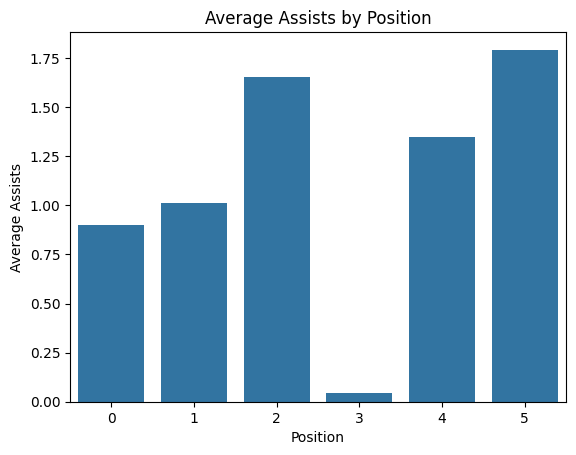

In [27]:
#assists by position
sns.barplot(data=data_means, x=data_means.index, y="Assists")
plt.title("Average Assists by Position")
plt.xlabel("Position")
plt.ylabel("Average Assists")
plt.show()

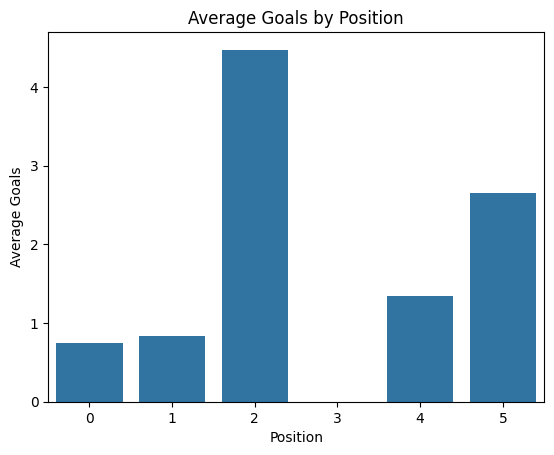

In [28]:
#goals by position
sns.barplot(data=data_means, x=data_means.index, y="Goals")
plt.title("Average Goals by Position")
plt.xlabel("Position")
plt.ylabel("Average Goals")
plt.show()

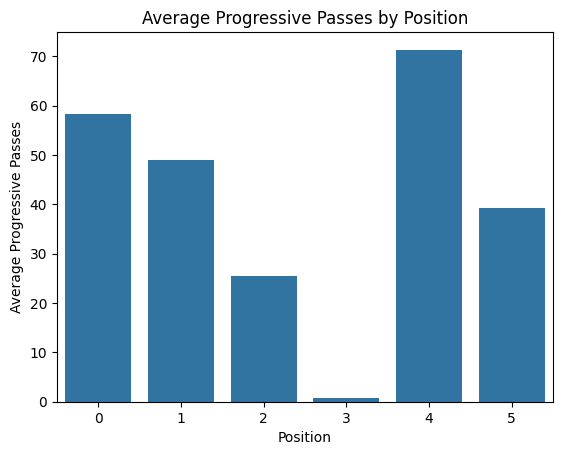

In [29]:
#progressive passes by position
sns.barplot(data=data_means, x=data_means.index, y="Progressive_Passes")
plt.title("Average Progressive Passes by Position")
plt.xlabel("Position")
plt.ylabel("Average Progressive Passes")
plt.show()

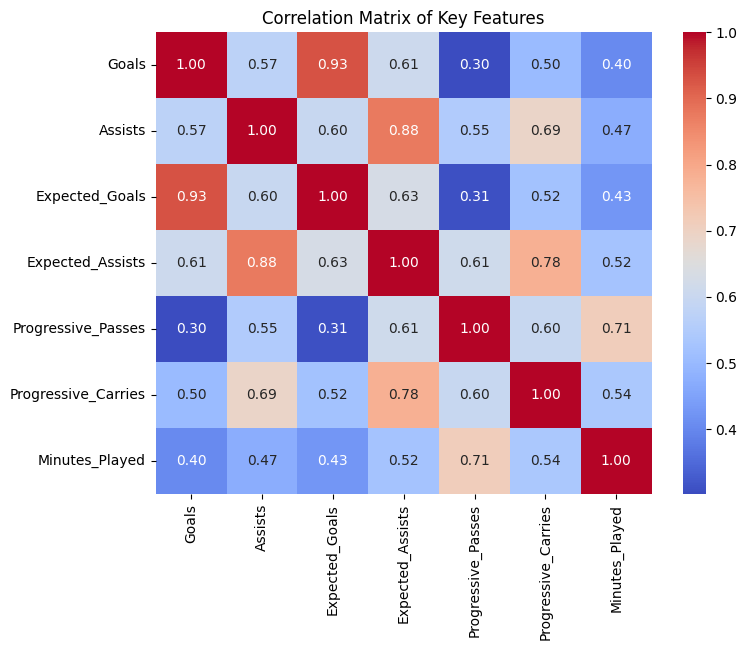

In [30]:
#correlation matrix
corr_features = ['Goals', 'Assists', 'Expected_Goals', 'Expected_Assists',
                 'Progressive_Passes', 'Progressive_Carries', 'Minutes_Played']
correlation_matrix = data_for_training[corr_features].corr()

#graphic
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Key Features")
plt.show()

### 3. MODELS CREATION


A) Predicting Future Performance

B) Player Comparison

C) Under or overrated: vair ser uma classificacao (regressao). Portanto random forest o linear.

## A) Predicting Future Performance (RandomForestRegressor)

Objective: Predict Goals and Assists Based on Expected Stats

The dataset contains some variables that are key indicators of a player's performance. Using these values, a RandomForestRegressor model can be trained to predict the actual Goals and Assists a player will achieve in a match.


In [31]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

X = data_for_training[['Expected_Goals', 'Expected_Assists', 'Progressive_Passes', 'Progressive_Carries', 'Minutes_Played']]
y_goals = data_for_training['Goals']
y_assists = data_for_training['Assists']

X_train, X_test, y_train_goals, y_test_goals = train_test_split(X, y_goals, test_size=0.2, random_state=42)
_, _, y_train_assists, y_test_assists = train_test_split(X, y_assists, test_size=0.2, random_state=42)

goals_model = RandomForestRegressor()
assists_model = RandomForestRegressor()

goals_model.fit(X_train, y_train_goals)
assists_model.fit(X_train, y_train_assists)

goals_preds = goals_model.predict(X_test)
assists_preds = assists_model.predict(X_test)

In [32]:
#predict for a new player
new_player = [[0.5, 0.3, 20, 15, 900]]  #example player stats
predicted_goals = goals_model.predict(new_player)
predicted_assists = assists_model.predict(new_player)

print(f"Predicted Goals: {predicted_goals[0]}")
print(f"Predicted Assists: {predicted_assists[0]}")

Predicted Goals: 0.3
Predicted Assists: 0.57


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [33]:
#predict for an existing player
player_name = "Ronald Araújo"

player_data = data_for_training[data['Player'] == player_name]

player_stats = player_data[['Expected_Goals', 'Expected_Assists', 'Progressive_Passes', 'Progressive_Carries', 'Minutes_Played']].values

predicted_goals = goals_model.predict(player_stats)
predicted_assists = assists_model.predict(player_stats)

print(f"Predicted Goals for {player_name}: {predicted_goals[0]}")
print(f"Predicted Assists for {player_name}: {predicted_assists[0]}")


Predicted Goals for Ronald Araújo: 2.75
Predicted Assists for Ronald Araújo: 1.39


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


## B) Player Comparison (KMeans Clustering)

The goal is to create a system that identifies players with similar statistical profiles based on the dataset. By grouping players into clusters with similar characteristics, it's possible to find players who share similar performance metrics.

The idea is to input the name of a player, extract their performance data from the dataset, and then use the clustering model to find players in the same cluster.

> Using KMeans but wanted to try Hierarchical clustering -> because of the number of clusters

In [34]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


X = data_for_training

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=8, random_state=42)
kmeans.fit(X_scaled)

data_for_training['Cluster'] = kmeans.labels_

new_data_for_training = data_for_training.copy()
new_data_for_training['Player'] = data['Player'].values

def similar_players(player_name):
    player_cluster = new_data_for_training[new_data_for_training['Player'] == player_name]['Cluster'].values[0]
    return new_data_for_training[(new_data_for_training['Cluster'] == player_cluster) & (new_data_for_training['Player'] != player_name)][['Player', 'Cluster']].head(10)

In [35]:
#example to find similar players
player_name = 'Iago Aspas'

if player_name in new_data_for_training['Player'].values:
    player_cluster = new_data_for_training[new_data_for_training['Player'] == player_name]['Cluster'].values[0]
    print(f"{player_name} is in the cluster: {player_cluster}")

    # Jugadores similares
    similares = similar_players(player_name)
    print("Similar players:")
    print(similares)
else:
    print("This player is not in the dataset.")

Iago Aspas is in the cluster: 3
Similar players:
                        Player  Cluster
91              Julián Álvarez        3
162  Pierre-Emerick Aubameyang        3
188                 Alex Baena        3
191                Leon Bailey        3
275            Jude Bellingham        3
283          Wissam Ben Yedder        3
310           Jan-Niklas Beste        3
352            Victor Boniface        3
374        Benjamin Bourigeaud        3
378               Jarrod Bowen        3


### C) Overrated/Underrated Classification (RandomForestClassifier)

Building a system that classifies whether a player is overperforming or underperforming based on their Expected Goals (xG) and Expected Assists (xA) compared to their actual performance.

The goal is to create a Performance_Label that indicates whether a player is exceeding expectations ("overperforming"), falling short ("underperforming"), or performing as expected ("well rated"). By training a model with this label, it can learn patterns in the players' stats to predict how other players are performing relative to their expectations.

In [36]:
from sklearn.ensemble import RandomForestClassifier
import numpy as np

#create the labels
data['Performance_Label'] = np.where(
    (data['Goals'] > data['Expected_Goals'] * 1.2) & (data['Assists'] > data['Expected_Assists'] * 1.2), 'Overperforming',
    np.where((data['Goals'] < data['Expected_Goals'] * 0.8) & (data['Assists'] < data['Expected_Assists'] * 0.8), 'Underperforming', 'Well Rated')
)

X = data[['Expected_Goals', 'Expected_Assists', 'Progressive_Passes', 'Progressive_Carries', 'Minutes_Played']]
y = data['Performance_Label']

performance_model = RandomForestClassifier()
performance_model.fit(X, y)


RandomForestClassifier()

In [37]:
#example predicting if a "new" player is overperforming o underperforming

new_player_stats = [[0.8, 0.6, 40, 25, 1200]]  #[xG, xA, prog_passes, prog_carries, minutes]

predicted_label = performance_model.predict(new_player_stats)
print(f"Player classification related to the stats: {predicted_label[0]}")


Player classification related to the stats: Well Rated


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [38]:
#example predicting how is an existing player performing
player_name = 'Jude Bellingham'

if player_name in data['Player'].values:
    player_row = data[data['Player'] == player_name]
    features = ['Expected_Goals', 'Expected_Assists', 'Progressive_Passes', 'Progressive_Carries', 'Minutes_Played']
    player_features = player_row[features].values

    predicted_label = performance_model.predict(player_features)
    print(f"{player_name} is classified as: {predicted_label[0]}")
else:
    print("This player is not in the dataset.")


Jude Bellingham is classified as: Well Rated


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


### 3. MODELS SERIALIZATION



In [39]:
import pickle

with open('goals_model.pkl', 'wb') as file:
    pickle.dump(goals_model, file)

with open('assists_model.pkl', 'wb') as file:
    pickle.dump(assists_model, file)

with open('clustering_model.pkl', 'wb') as file:
    pickle.dump(kmeans, file)

with open('performance_model.pkl', 'wb') as file:
    pickle.dump(performance_model, file)


- To load the model:

with open('goals_model.pkl', 'rb') as file:
    loaded_goals_model = pickle.load(file)
